In [60]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import albumentations as A
from skimage import io
from pathlib import Path
import cv2
from transformers import ViTModel, ViTConfig
import warnings
warnings.filterwarnings('ignore')

## Configuration

In [61]:
# Paths
sample_images_dir = Path(r"E:\Projects\HTR_PR_Lab\HTR-Pipeline\notebook\sample_images")
lines_txt_path = Path(r"E:\Projects\HTR_PR_Lab\HTR-Pipeline\datasets\IAM\ascii\lines.txt")

# Model configuration
image_size = 1024
num_characters = 5  # First 5 characters

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


## Load Ground Truth Transcriptions

In [62]:
def load_line_transcriptions(lines_txt_path):
    """Load transcriptions from IAM lines.txt file."""
    transcriptions = {}
    
    with open(lines_txt_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            
            parts = line.split()
            if len(parts) < 9:
                continue
            
            line_id = parts[0]
            # Join words with spaces, removing the pipe separators
            text = ' '.join(parts[8:]).replace('|', ' ')
            transcriptions[line_id] = text
    
    return transcriptions

transcriptions = load_line_transcriptions(lines_txt_path)
print(f"Loaded {len(transcriptions)} transcriptions")

# Show sample transcriptions
for img_file in sorted(sample_images_dir.glob('*.png'))[:3]:
    line_id = img_file.stem
    if line_id in transcriptions:
        print(f"{line_id}: {transcriptions[line_id][:50]}...")

Loaded 13353 transcriptions
c04-110-00: Become a success with a disc and hey presto ! You ...
c04-110-01: assuredness " Bella Bella Marie " ( Parlophone ) ,...
c04-110-02: I don't think he will storm the charts with this o...


## Image Preprocessing

In [63]:
def get_image(img_path, shape=image_size):
    """Load and preprocess image for ViT model."""
    img = io.imread(img_path)
    
    # Convert grayscale to RGB
    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)
    
    # If RGBA → drop alpha
    if img.shape[-1] > 3:
        img = img[:, :, :3]
    
    org_img = img.copy()
    
    # Normalize
    img = A.Normalize()(image=img)["image"]
    
    # Convert to tensor
    img = np.transpose(img, (2, 0, 1))
    img = np.expand_dims(img, 0)
    img = torch.tensor(img, dtype=torch.float32)
    
    # Resize
    img = nn.Upsample((shape, shape), mode='bilinear', align_corners=False)(img)
    
    return img, org_img


def preprocess_image_array(img, shape=image_size):
    """Preprocess a numpy array image for ViT model."""
    # Convert grayscale to RGB if needed
    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)
    
    # If RGBA → drop alpha
    if img.shape[-1] > 3:
        img = img[:, :, :3]
    
    org_img = img.copy()
    
    # Normalize
    img = A.Normalize()(image=img)["image"]
    
    # Convert to tensor
    img = np.transpose(img, (2, 0, 1))
    img = np.expand_dims(img, 0)
    img = torch.tensor(img, dtype=torch.float32)
    
    # Resize
    img = nn.Upsample((shape, shape), mode='bilinear', align_corners=False)(img)
    
    return img, org_img

## Load ViT Model

In [64]:
# Load ViT model
config = ViTConfig.from_pretrained("google/vit-base-patch16-384")
config.image_size = image_size

model = ViTModel.from_pretrained(
    "google/vit-base-patch16-384",
    config=config,
    ignore_mismatched_sizes=True
).to(device)

model.set_attn_implementation('eager')
model.eval()

print(f"Model loaded on {device}")

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-384 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-384 and are newly initialized because the shapes did not match:
- embeddings.position_embeddings: found shape torch.Size([1, 577, 768]) in the checkpoint and torch.Size([1, 4097, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded on cuda


## Extract Character-Level Attention Maps

In [65]:
def extract_attention_map(model, img, device):
    """Extract attention maps from ViT model."""
    with torch.no_grad():
        output = model(
            pixel_values=img.to(device),
            output_attentions=True,
            output_hidden_states=True,
            interpolate_pos_encoding=True,
            return_dict=True
        )
    
    # Get attention from last layer
    attentions = output["attentions"][-1]  # Shape: [1, num_heads, num_patches+1, num_patches+1]
    
    # Average across all attention heads
    attention_map = attentions.mean(dim=1)  # Shape: [1, num_patches+1, num_patches+1]
    
    # Get attention from CLS token to all patches
    attention_map = attention_map[:, 0, :]  # Shape: [1, num_patches+1]
    
    # Remove CLS token attention
    attention_map = attention_map[:, 1:]  # Shape: [1, num_patches]
    
    return attention_map


def segment_words_from_image(image, text, num_words=1):
    """Segment image into word patches based on horizontal projection and text.
    Improved to properly crop the first word with better boundary detection.
    
    Args:
        image: Original grayscale or RGB image
        text: Ground truth text
        num_words: Number of words to extract
    
    Returns:
        List of word patches with metadata
    """
    # Convert to grayscale if needed
    if image.ndim == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image.copy()
    
    # Apply Otsu's thresholding for better binary conversion
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Calculate horizontal projection (sum along vertical axis)
    horizontal_projection = np.sum(binary, axis=0)
    
    # Adaptive threshold based on projection statistics
    threshold = np.mean(horizontal_projection[horizontal_projection > 0]) * 0.15
    
    # Find word boundaries using gaps in horizontal projection
    in_word = False
    word_boundaries = []
    start_x = 0
    min_gap_width = 3  # Minimum gap width to separate words
    gap_count = 0
    
    for x in range(len(horizontal_projection)):
        if horizontal_projection[x] > threshold:
            if not in_word:
                start_x = x
                in_word = True
                gap_count = 0
        else:
            if in_word:
                gap_count += 1
                # End word if gap is wide enough
                if gap_count >= min_gap_width:
                    word_boundaries.append((start_x, x - gap_count))
                    in_word = False
    
    # Handle last word if image ends with text
    if in_word:
        word_boundaries.append((start_x, len(horizontal_projection)))
    
    # Get words from text
    words = text.split()[:num_words]
    
    # Extract word patches with minimal padding
    word_patches = []
    for idx, (start_x, end_x) in enumerate(word_boundaries[:len(words)]):
        if idx >= len(words):
            break
            
        # Add small padding (2-3 pixels) to avoid cutting off character edges
        padding = 2
        start_x = max(0, start_x - padding)
        end_x = min(image.shape[1], end_x + padding)
        
        # Ensure we have some width
        if end_x - start_x < 10:
            continue
        
        # Extract word patch - full height of the line
        word_patch = image[:, start_x:end_x].copy()
        
        word_patches.append({
            'word': words[idx],
            'patch': word_patch,
            'boundaries': (start_x, end_x),
            'index': idx
        })
    
    return word_patches


def create_character_attention_map_for_word(attention_map, char_position, word_length, image_size=1024, original_shape=None):
    """Create attention map focused on specific character within a word patch.
    
    Args:
        attention_map: Full attention map [1, num_patches]
        char_position: Character position within the word (0-based: 0 for 1st, 1 for 2nd, etc.)
        word_length: Total number of characters in the word
        image_size: Processing image size
        original_shape: Original word patch shape (H, W)
    """
    # Reshape to 2D grid
    num_patches = attention_map.shape[1]
    map_size = int(np.sqrt(num_patches))
    attention_map_2d = attention_map.view(1, 1, map_size, map_size)
    
    # Calculate character width in patch space
    # For a word patch, divide horizontal space by number of characters
    char_width_patches = map_size / word_length
    center_col = int((char_position + 0.5) * char_width_patches)
    
    # Create focused mask for the character
    mask_width = max(2, int(char_width_patches * 1.3))  # Slightly wider for better coverage
    start_col = max(0, center_col - mask_width // 2)
    end_col = min(map_size, start_col + mask_width)
    
    # Create Gaussian-like mask for smoother localization
    mask = torch.zeros_like(attention_map_2d)
    for col in range(start_col, end_col):
        # Gaussian weight based on distance from center
        dist = abs(col - center_col) / (mask_width / 2) if mask_width > 0 else 0
        weight = np.exp(-dist ** 2)
        mask[:, :, :, col] = weight
    
    # Apply mask to attention
    char_attention = attention_map_2d * mask
    
    # Normalize to [0, 1]
    max_val = char_attention.max()
    if max_val > 0:
        char_attention = char_attention / max_val
    
    # Upsample to match original word patch dimensions
    if original_shape is not None:
        char_attention = nn.Upsample(
            size=(original_shape[0], original_shape[1]),
            mode='bilinear',
            align_corners=False
        )(char_attention)
    else:
        char_attention = nn.Upsample(
            size=(image_size, image_size),
            mode='bilinear',
            align_corners=False
        )(char_attention)
    
    return char_attention[0, 0].cpu().numpy()


## Process All Images and Extract Character Attention Maps

In [66]:
# Collect all data
image_files = sorted(sample_images_dir.glob('*.png'))
data = []

# Standard size for uniform word patches
STANDARD_WORD_HEIGHT = 64
STANDARD_WORD_WIDTH = 256

print(f"Processing {len(image_files)} images...\n")
print(f"Standard word patch size: {STANDARD_WORD_HEIGHT}x{STANDARD_WORD_WIDTH}\n")

for img_file in image_files:
    line_id = img_file.stem
    
    if line_id not in transcriptions:
        print(f"Skipping {line_id}: no transcription found")
        continue
    
    text = transcriptions[line_id]
    words = text.split()
    
    if not words or len(words[0]) < num_characters:
        print(f"Skipping {line_id}: first word too short")
        continue
    
    print(f"Processing {line_id}: Text='{text[:60]}...'")
    
    # Load original image
    img_tensor, org_img = get_image(str(img_file))
    
    # Segment image into word patches
    word_patches = segment_words_from_image(org_img, text, num_words=1)
    
    if not word_patches:
        print(f"  Warning: Could not segment words from {line_id}")
        continue
    
    first_word_data = word_patches[0]
    word_patch_original = first_word_data['patch']
    first_word = first_word_data['word']
    
    print(f"  Extracted word: '{first_word}' with original shape {word_patch_original.shape}")
    
    # Resize word patch to standard size for uniform visualization
    word_patch_resized = cv2.resize(
        word_patch_original, 
        (STANDARD_WORD_WIDTH, STANDARD_WORD_HEIGHT),
        interpolation=cv2.INTER_AREA
    )
    print(f"  Resized to standard shape: {word_patch_resized.shape}")
    
    # Process the resized word patch through model
    word_img_tensor, _ = preprocess_image_array(word_patch_resized)
    
    # Extract attention map for the word patch
    attention_map = extract_attention_map(model, word_img_tensor, device)
    
    # Create character-specific attention maps for first 5 characters
    char_attention_maps = []
    first_chars = first_word[:num_characters]
    
    for char_idx in range(min(num_characters, len(first_word))):
        char_attn = create_character_attention_map_for_word(
            attention_map,
            char_idx,
            len(first_word),
            image_size=image_size,
            original_shape=word_patch_resized.shape[:2]  # Use resized shape
        )
        char_attention_maps.append(char_attn)
    
    data.append({
        'line_id': line_id,
        'text': text,
        'first_word': first_word,
        'first_chars': first_chars,
        'word_patch': word_patch_resized,  # Store resized uniform patch
        'char_attention_maps': char_attention_maps
    })

print(f"\nSuccessfully processed {len(data)} images")
print(f"All word patches standardized to: {STANDARD_WORD_HEIGHT}x{STANDARD_WORD_WIDTH}")


Processing 8 images...

Standard word patch size: 64x256

Processing c04-110-00: Text='Become a success with a disc and hey presto ! You 're a star...'
  Extracted word: 'Become' with original shape (40, 64, 3)
  Resized to standard shape: (64, 256, 3)
Processing c04-110-01: Text='assuredness " Bella Bella Marie " ( Parlophone ) , a lively ...'
  Extracted word: 'assuredness' with original shape (48, 21, 3)
  Resized to standard shape: (64, 256, 3)
Skipping c04-110-02: first word too short
Processing c04-110-03: Text='CHRIS CHARLES , 39 , who lives in Stockton-on-Tees , is an a...'
  Extracted word: 'CHRIS' with original shape (32, 35, 3)
  Resized to standard shape: (64, 256, 3)
Skipping c04-116-00: first word too short
Processing c04-116-01: Text='writer . He writes with Tolchard Evans , composer of " Lady ...'
  Extracted word: 'writer' with original shape (38, 22, 3)
  Resized to standard shape: (64, 256, 3)
Processing c04-116-02: Text='Tolch , as he is known in Tin Pan Alley , lik

## Create Final Visualization (Fig. 5 Style)

Grid layout:
- Rows: Different handwritten lines
- Columns: Character 1, Character 2, Character 3, Character 4, Character 5


Visualization saved to: E:\Projects\HTR_PR_Lab\HTR-Pipeline\notebook\character_attention_visualization.png


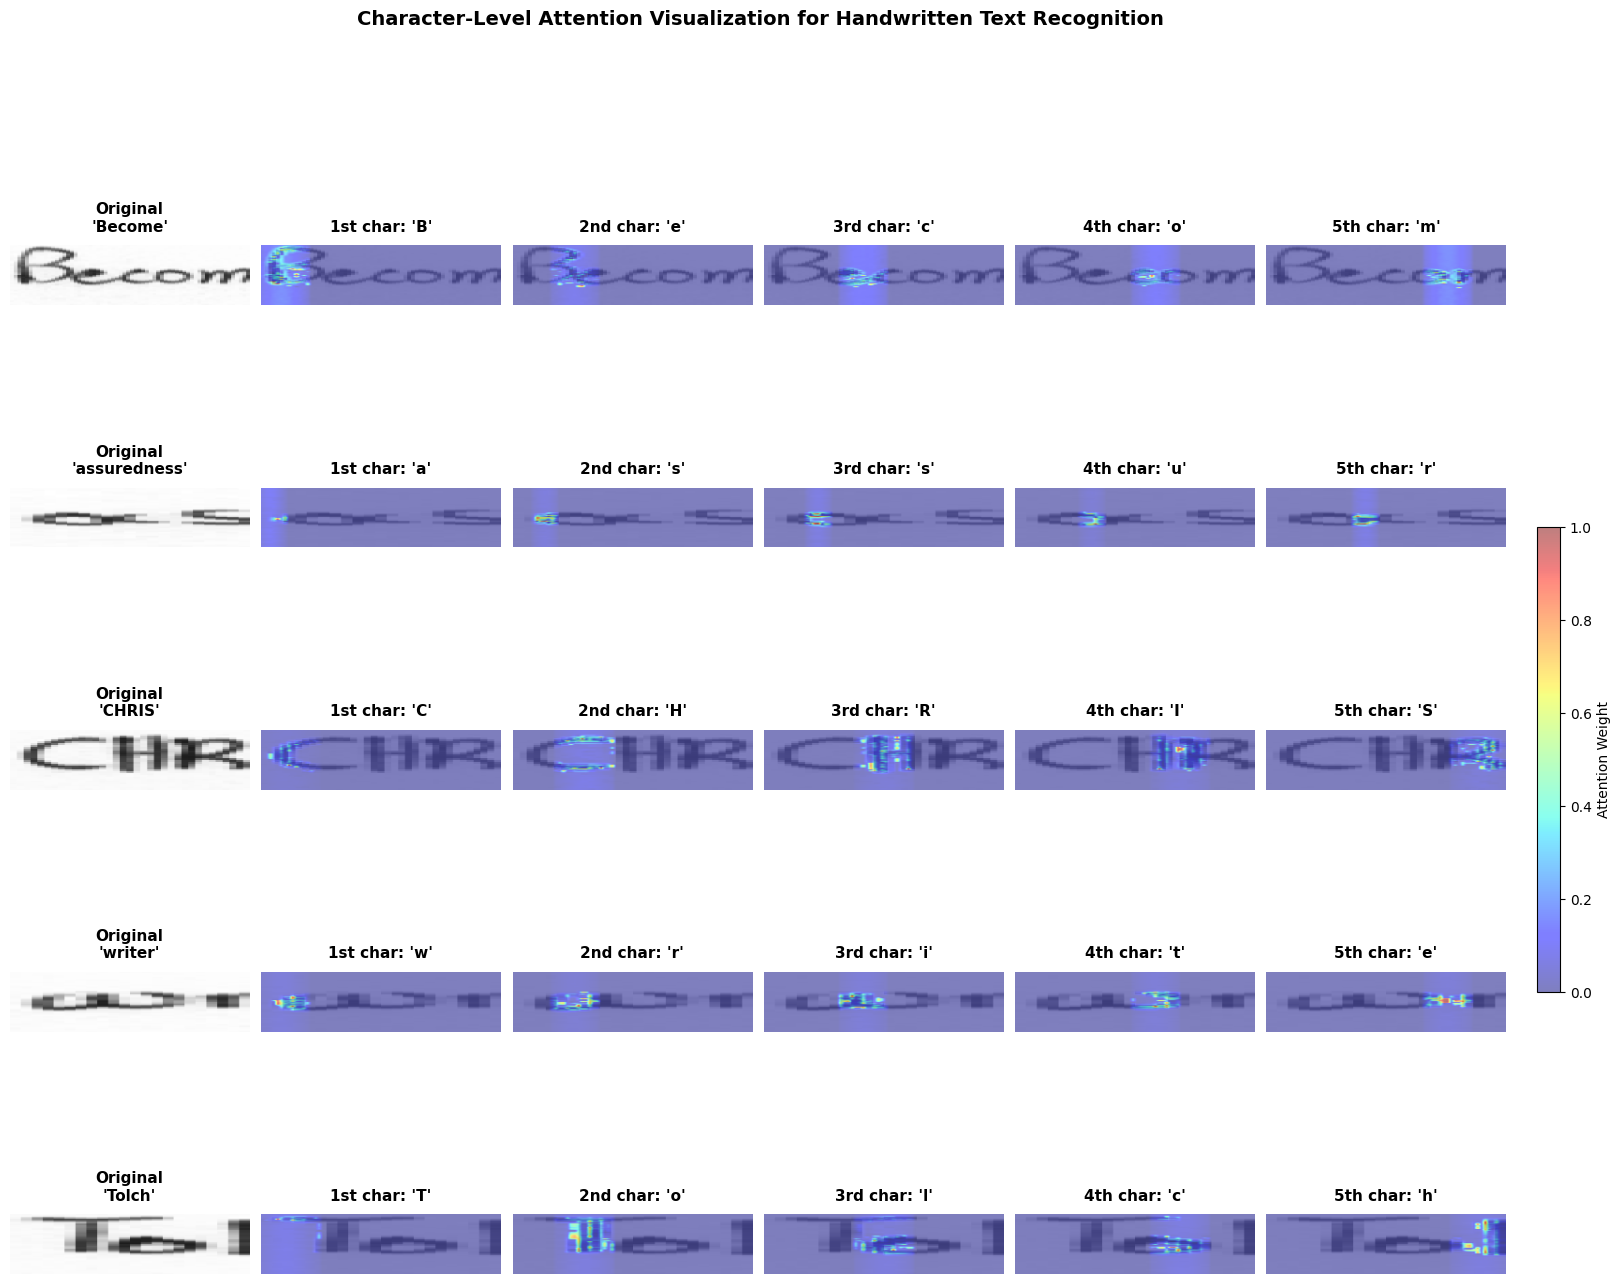

In [67]:
def create_attention_visualization(data, num_characters=5, figsize=(20, 3)):
    """Create character-level attention visualization similar to Fig. 5.
    Shows original cropped word followed by character-wise attention overlays.
    """
    
    num_lines = len(data)
    
    # Adjust figure size based on number of lines
    figsize = (20, 3 * num_lines)
    
    # Create figure with subplots
    fig, axes = plt.subplots(
        num_lines,
        num_characters + 1,  # +1 for original word patch column
        figsize=figsize,
        gridspec_kw={'wspace': 0.05, 'hspace': 0.3}
    )
    
    # If only one line, make axes 2D
    if num_lines == 1:
        axes = axes.reshape(1, -1)
    
    # Process each line
    for row_idx, item in enumerate(data):
        word_patch = item['word_patch']
        char_maps = item['char_attention_maps']
        first_chars = item['first_chars']
        first_word = item['first_word']
        
        # Prepare display image (convert to RGB if grayscale)
        if word_patch.ndim == 2:
            display_img = cv2.cvtColor(word_patch, cv2.COLOR_GRAY2RGB)
        else:
            display_img = word_patch.copy()
        
        # Normalize display image for better visibility
        display_img = display_img.astype(np.float32)
        if display_img.max() > 0:
            display_img = display_img / display_img.max()
        
        # Column 0: Original word patch (properly cropped)
        ax = axes[row_idx, 0]
        ax.imshow(display_img, cmap='gray' if word_patch.ndim == 2 else None)
        ax.set_title(f"Original\n'{first_word}'", fontsize=11, fontweight='bold', pad=10)
        ax.axis('off')
        
        # Columns 1-5: Character-wise attention overlays (1st, 2nd, 3rd, 4th, 5th char)
        for char_idx in range(len(char_maps)):
            ax = axes[row_idx, char_idx + 1]
            
            attn_map = char_maps[char_idx]
            
            # Display base image with slight transparency
            ax.imshow(display_img, alpha=0.6)
            
            # Overlay character-specific attention heatmap with 'jet' colormap
            im = ax.imshow(
                attn_map,
                cmap='jet',  # Blue→Cyan→Green→Yellow→Red
                alpha=0.5,
                vmin=0,
                vmax=1,
                interpolation='bilinear'
            )
            
            # Set title with character position (1st, 2nd, 3rd, etc.)
            char = first_chars[char_idx]
            position_suffix = ['st', 'nd', 'rd'] + ['th'] * 7
            position_label = f"{char_idx + 1}{position_suffix[char_idx]}"
            ax.set_title(f"{position_label} char: '{char}'", fontsize=11, fontweight='bold', pad=10)
            ax.axis('off')
        
        # Hide unused subplots if fewer than num_characters
        for char_idx in range(len(char_maps), num_characters):
            axes[row_idx, char_idx + 1].axis('off')
    
    # Add colorbar
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation='vertical', 
                        fraction=0.015, pad=0.02, label='Attention Weight')
    cbar.ax.tick_params(labelsize=10)
    
    # Add super title
    fig.suptitle(
        'Character-Level Attention Visualization for Handwritten Text Recognition',
        fontsize=14,
        fontweight='bold',
        y=0.995
    )
    
    plt.tight_layout(rect=[0, 0, 0.98, 0.99])
    
    return fig


# Create visualization
fig = create_attention_visualization(data, num_characters=num_characters)

# Save figure
output_path = sample_images_dir.parent / 'character_attention_visualization.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved to: {output_path}")

plt.show()


## Alternative: Individual Line Visualizations

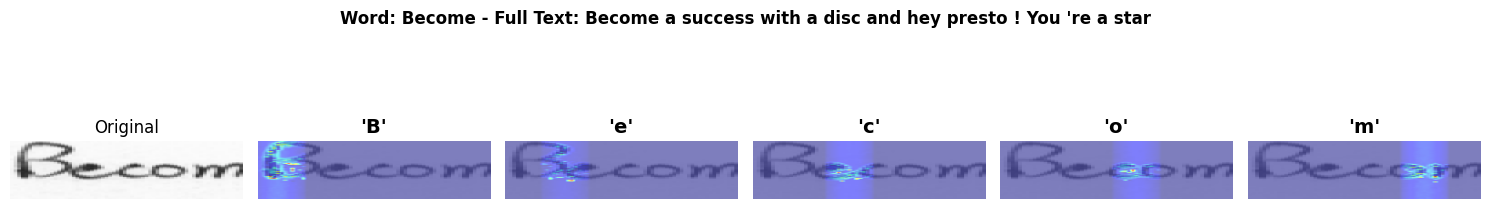

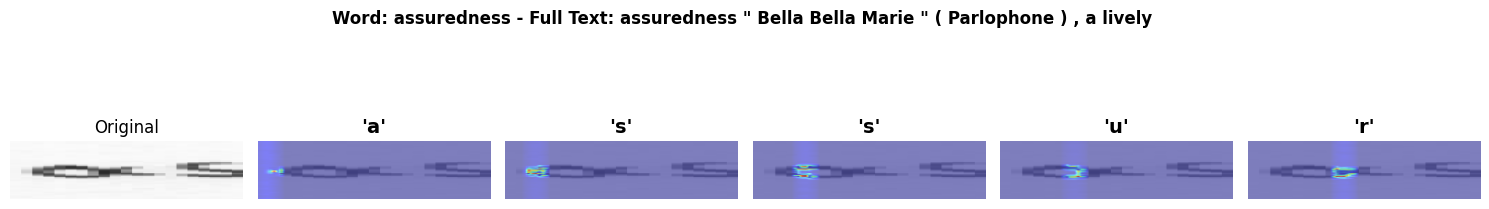

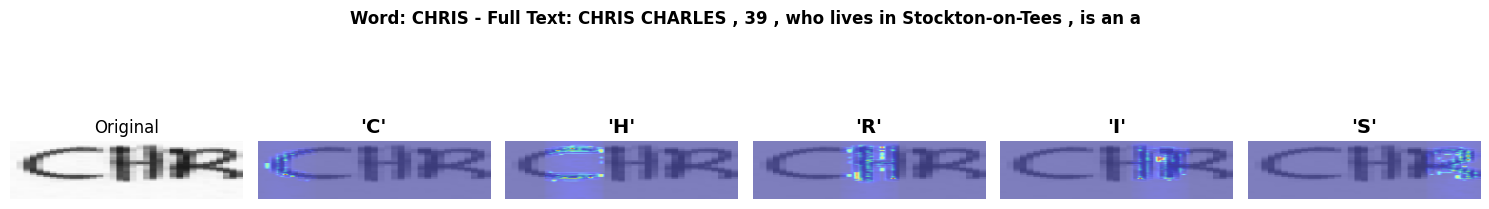

In [68]:
def visualize_single_line(item, num_characters=5, figsize=(15, 3)):
    """Create detailed visualization for a single word."""
    
    fig, axes = plt.subplots(1, num_characters + 1, figsize=figsize)
    
    word_patch = item['word_patch']
    char_maps = item['char_attention_maps']
    first_chars = item['first_chars']
    
    # Original word patch
    axes[0].imshow(word_patch, cmap='gray' if word_patch.ndim == 2 else None)
    axes[0].set_title('Original', fontsize=12)
    axes[0].axis('off')
    
    # Character attention maps
    for char_idx in range(len(char_maps)):
        attn_map = char_maps[char_idx]
        
        if word_patch.ndim == 3:
            display_img = word_patch.copy()
        else:
            display_img = cv2.cvtColor(word_patch, cv2.COLOR_GRAY2RGB)
        
        axes[char_idx + 1].imshow(display_img, alpha=0.6)
        axes[char_idx + 1].imshow(attn_map, cmap='jet', alpha=0.5, vmin=0, vmax=1)
        axes[char_idx + 1].set_title(f"'{first_chars[char_idx]}'", fontsize=14, fontweight='bold')
        axes[char_idx + 1].axis('off')
    
    fig.suptitle(f"Word: {item['first_word']} - Full Text: {item['text'][:60]}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig

# Visualize each word individually
for item in data[:3]:  # Show first 3 words
    fig = visualize_single_line(item)
    plt.show()

## Export Data for Further Analysis

In [69]:
# Save processed data
import pickle

output_data_path = sample_images_dir.parent / 'character_attention_data.pkl'
with open(output_data_path, 'wb') as f:
    pickle.dump(data, f)

print(f"Data saved to: {output_data_path}")
print(f"\nSummary:")
print(f"- Total lines processed: {len(data)}")
print(f"- Characters per line: {num_characters}")
print(f"- Attention maps per line: {num_characters}")

Data saved to: E:\Projects\HTR_PR_Lab\HTR-Pipeline\notebook\character_attention_data.pkl

Summary:
- Total lines processed: 5
- Characters per line: 5
- Attention maps per line: 5
